In [2]:
# Libraries
import sys
sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt
import json
import torch
from torch import nn
from data_processors import *
from scipy.stats import sem, t
import os
from tqdm import tqdm
from policies import DeepGaussianPolicy
from envs import PendulumEnv
from data_processors import KernelDataProcessor
import copy
import math
import imageio
import random
import pandas as pd
import seaborn as sns

/home/tedeschi_bpo/miniconda3/envs/RlEnv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
# Funzione per caricare i dati da un percorso
def load_trials(base_path, n_exp):
    trial_performances = []
    for i in range(n_exp):
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    trial_performances.append(data["performance"])
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nel leggere {file_path}: {e}")
    return np.array(trial_performances)  # Converte in array per calcoli successivi

In [9]:
paths = [
    "/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{0.25}kl{0}_07_24-01_47_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_025_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{0.5}kl{0}_07_24-03_30_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_05_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{0.75}kl{0}_07_24-05_18_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_075_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{1}kl{0}_07_24-07_04_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{1.5}kl{0}_07_24-08_50_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00",

    # using optimization lr 1e-2
    "/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl2_retrain/std{0.25}kl{0}_07_25-21_06_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_025_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl2_retrain/std{0.75}kl{0}_07_25-23_34_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_075_noise_00"

]


In [10]:
# Lista per memorizzare le performance per ogni set
all_performances = []

for path in paths:
    performances = load_trials(path, n_exp=10)
    if performances.size > 0:
        all_performances.append(performances)

lab = ['std 0.25', 'std 0.5', 'std 0.75', 'std 1', 'std 1.5', 'a', 'b']
print(len(all_performances))

7


-1.6710363610500962
-1.5358762901157053
-1.511935559665946
-1.5313037663660956
-1.5811768343190875
-1.8566184009940185
-1.5495457342216699


<Figure size 640x480 with 0 Axes>

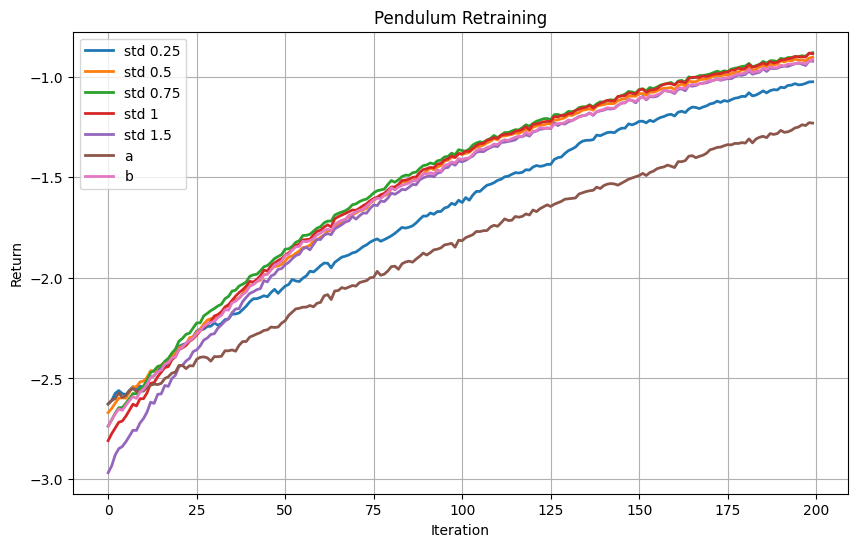

In [11]:
# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(10, 6))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, linewidth=2, label = lab[i])

        # Plot dell'intervallo di confidenza
        lower = mean_performance-(std_performance)*1.96/np.sqrt(performances.shape[0])
        higher = mean_performance+(std_performance)*1.96/np.sqrt(performances.shape[0])

        plt.fill_between(
            range(len(mean_performance)),
            lower,
            higher,
            alpha=0.2
        )

        print(np.mean(mean_performance))
        # print(np.mean(lower))
        # print(np.mean(higher))

# Etichette e titolo
plt.title("Pendulum Retraining")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend()
plt.grid()
# plt.ylim(bottom=-80)
# plt.xlim(right=80)
# Salva e mostra il grafico
# plt.savefig("dam_1825_b10_g999.pdf", format='pdf')
plt.show()

In [12]:
def load_cost(trial_path):
    costs = []
    if os.path.isdir(trial_path):
        try:
            file_path = os.path.join(trial_path, "results.json")
            with open(file_path, 'r') as file:
                data = json.load(file)
                costs.append(data["cost"])
        except (FileNotFoundError, json.JSONDecodeError) as e:
            print(f"Errore nel leggere {file_path}: {e}")
    return np.array(costs)  

In [18]:
HORIZON = 200
GAMMA = 0.99
FRICTION = 0.3
STD_DEV = 0.25

NUM_EPISODES = 200

START = "down"
SEED = 42  
random.seed(SEED)
np.random.seed(SEED)

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = FRICTION, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )

policies = [
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{0.25}kl{0}_07_24-01_47_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_025_noise_00/trial_0", 0.25, 0],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{0.5}kl{0}_07_24-03_30_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_05_noise_00/trial_0", 0.5, 0],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{0.75}kl{0}_07_24-05_18_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0", 0.75, 0],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{1}kl{0}_07_24-07_04_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0", 1, 0],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{1.5}kl{0}_07_24-08_50_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0", 1.5, 0],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{0.25}kl{5}_07_24-10_34_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_025_noise_00/trial_0", 0.25, 5],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{0.5}kl{5}_07_24-12_18_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_05_noise_00/trial_0", 0.5, 5],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{0.75}kl{5}_07_24-14_04_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0", 0.75, 5],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{1}kl{5}_07_24-15_53_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0", 1, 5],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{1.5}kl{5}_07_24-17_37_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0", 1.5, 5],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{0.25}kl{10}_07_24-19_24_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_025_noise_00/trial_0", 0.25, 10],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{0.5}kl{10}_07_24-21_09_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_05_noise_00/trial_0", 0.5, 10],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{0.75}kl{10}_07_24-22_55_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0", 0.75, 10],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{1}kl{10}_07_25-00_40_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0", 1, 10],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{1.5}kl{10}_07_25-02_22_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0", 1.5, 10],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{0.25}kl{15}_07_25-04_09_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_025_noise_00/trial_0", 0.25, 15],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{0.5}kl{15}_07_25-05_49_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_05_noise_00/trial_0", 0.5, 15],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{0.75}kl{15}_07_25-07_36_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0", 0.75, 15],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{1}kl{15}_07_25-09_20_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0", 1, 15],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{1.5}kl{15}_07_25-11_05_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0", 1.5, 15],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{0.25}kl{20}_07_25-12_50_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_025_noise_00/trial_0", 0.25, 20],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{0.5}kl{20}_07_25-14_36_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_05_noise_00/trial_0", 0.5, 20],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{0.75}kl{20}_07_25-16_21_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0", 0.75, 20],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_retrain/std{1}kl{20}_07_25-18_07_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0", 1, 20],

    # ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl2_retrain/std{0.25}kl{0}_07_25-21_06_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_025_noise_00", 0.25, 0],
    # ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl2_retrain/std{0.75}kl{0}_07_25-23_34_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_075_noise_00", 0.75, 0]


]
data = []

for policy in policies :
    random.seed(SEED)
    np.random.seed(SEED)        
    pol = DeepGaussianPolicy(
                parameters=np.load(policy[0] +"/policy_params.npy"),
                output_size=a_dim,
                model=copy.deepcopy(net),
                model_desc=copy.deepcopy(model_desc),
                std_dev=STD_DEV,
                std_decay=0,
                std_min=1e-6
            )
    dp = KernelDataProcessor()

    all_episode_rewards = []
    for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
        episode_rewards = []
        done = False
        env.reset(options={"start": START}, seed = i)
        for t in range(HORIZON): # iterate over the steps until termination
            obs = env.state
            obs = dp.transform(obs)
            action = pol.draw_action(obs)
            obs, rew, done, _ = env.step(action)
            episode_rewards.append(rew * GAMMA ** t)
            if done:
                break
        all_episode_rewards.append(sum(episode_rewards))

    mean_episode_reward = np.mean(all_episode_rewards)
    std_episode_reward = np.std(all_episode_rewards)
    print("Mean reward:", mean_episode_reward,
            "Std reward:", std_episode_reward)


    # plt.plot(all_episode_rewards, linewidth=2, label="reward")
    # plt.title("Cartpole Reward")
    # plt.xlabel("episode")
    # plt.ylabel("Return")
    # plt.grid()

    # plt.title("Pendulum Cost")
    # plt.xlabel("episode")
    # plt.ylabel("Return")
    # plt.grid()
    # plt.legend()
    # plt.show
    mean_cost = np.mean(load_cost(policy[0]))

    data.append({
        'mean_reward' : mean_episode_reward,
        'std_reward' : std_episode_reward,
        'behavioural_std' : policy[1],
        'kl_coefficient' : policy[2],
        'cost' : mean_cost

    })


  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:18<00:00, 11.08it/s]


Mean reward: -393.2720947080781 Std reward: 119.36863708165922


100%|██████████| 200/200 [00:11<00:00, 17.06it/s]


Mean reward: -393.21848279257034 Std reward: 119.37734759555838


...

Mean reward: -393.21067823841514 Std reward: 119.37517129233674


100%|██████████| 200/200 [00:18<00:00, 10.63it/s]


Mean reward: -393.20536074888076 Std reward: 119.38336504179199


100%|██████████| 200/200 [00:13<00:00, 15.07it/s]

Mean reward: -393.1537012602689 Std reward: 119.4045404173102


In [19]:
df = pd.DataFrame(data)
df

,mean_reward,std_reward,behavioural_std,kl_coefficient,cost
0,-393.272095,119.368637,0.25,0,-1.684827
1,-393.218483,119.377348,0.50,0,-1.545251
2,-393.214215,119.381085,0.75,0,-1.520115
3,-393.202657,119.389092,1.00,0,-1.537191
4,-393.164860,119.406448,1.50,0,-1.587467
5,-393.271576,119.368224,0.25,5,-1.692503
6,-393.211019,119.378778,0.50,5,-1.506470
7,-393.219229,119.378957,0.75,5,-1.528417
8,-393.195384,119.390486,1.00,5,-1.518354
9,-393.137525,119.415796,1.50,5,-1.582123


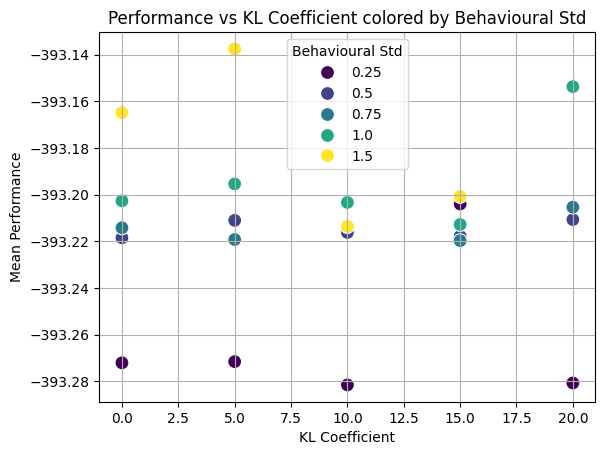

In [20]:
sns.scatterplot(
    data=df,
    x='kl_coefficient',
    y='mean_reward',
    hue='behavioural_std',  # color by this column
    palette='viridis',      # or try: 'coolwarm', 'plasma', etc.
    s=100                   # point size
)

plt.xlabel("KL Coefficient")
plt.ylabel("Mean Performance")
plt.title("Performance vs KL Coefficient colored by Behavioural Std")
plt.grid(True)
plt.legend(title="Behavioural Std")
plt.show()

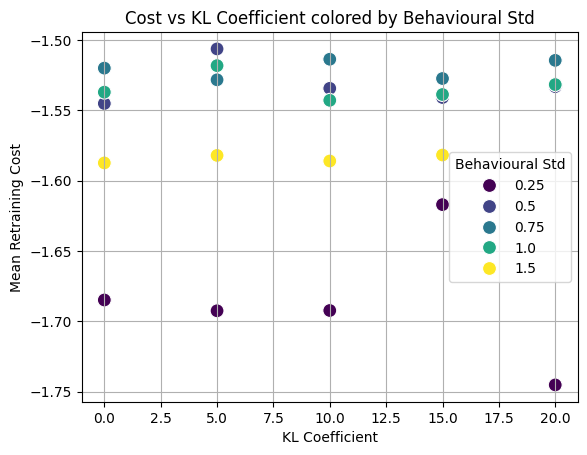

In [21]:
sns.scatterplot(
    data=df,
    x='kl_coefficient',
    y='cost',
    hue='behavioural_std',  # color by this column
    palette='viridis',      # or try: 'coolwarm', 'plasma', etc.
    s=100                   # point size
)

plt.xlabel("KL Coefficient")
plt.ylabel("Mean Retraining Cost")
plt.title("Cost vs KL Coefficient colored by Behavioural Std")
plt.grid(True)
plt.legend(title="Behavioural Std")
plt.show()

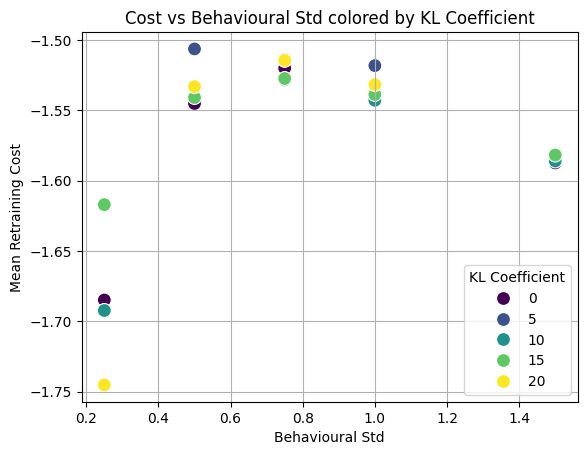

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x='behavioural_std',  # X-axis: behavioural_std
    y='cost',              # Y-axis: cost
    hue='kl_coefficient',  # Color points by kl_coefficient
    palette='viridis',
    s=100
)

plt.xlabel("Behavioural Std")
plt.ylabel("Mean Retraining Cost")
plt.title("Cost vs Behavioural Std colored by KL Coefficient")
plt.grid(True)
plt.legend(title="KL Coefficient")
plt.show()


In [3]:
def load_cost(trial_path):
    costs = []
    if os.path.isdir(trial_path):
        try:
            file_path = os.path.join(trial_path, "results.json")
            with open(file_path, 'r') as file:
                data = json.load(file)
                costs.append(data["cost"])
        except (FileNotFoundError, json.JSONDecodeError) as e:
            print(f"Errore nel leggere {file_path}: {e}")
    return np.array(costs)  

In [ ]:
# cost retarining at mu 0.3
paths = [
    '/home/tedeschi_bpo/learn_RL/results/pendulum_friction/retrainfrom0/test{0.3}_07_10-22_25_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_02_noise_00/trial_0'
]
all_costs = []
for path in paths:
    costs= load_cost(path)
    if costs.size > 0:
        all_costs.append(costs)

plt.figure(figsize=(10, 6))
for i, costs in enumerate(all_costs):
    costs = costs[0]
    plt.plot(costs, label=f"Path {i+1}", linewidth=2)
    print(f"Path {i+1} - Mean Cost: {np.mean(costs):.2f}, Std Dev: {np.std(costs):.2f}")

plt.title("Pendulum Cost")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.legend()
plt.grid()




  0%|          | 1/5000 [00:00<08:40,  9.60it/s]

current mu = 0


 20%|██        | 1002/5000 [01:08<04:17, 15.50it/s]

current mu = 0.1


 40%|████      | 2002/5000 [02:13<03:38, 13.73it/s]

...

current mu = 0.3
 ------- Simulating retrain at mu = 0.3


 80%|████████  | 4002/5000 [04:28<01:01, 16.30it/s]

current mu = 0.4


100%|██████████| 5000/5000 [05:36<00:00, 14.84it/s]


Mean reward: -5.035886880463715 Std reward: 46.11052394470344


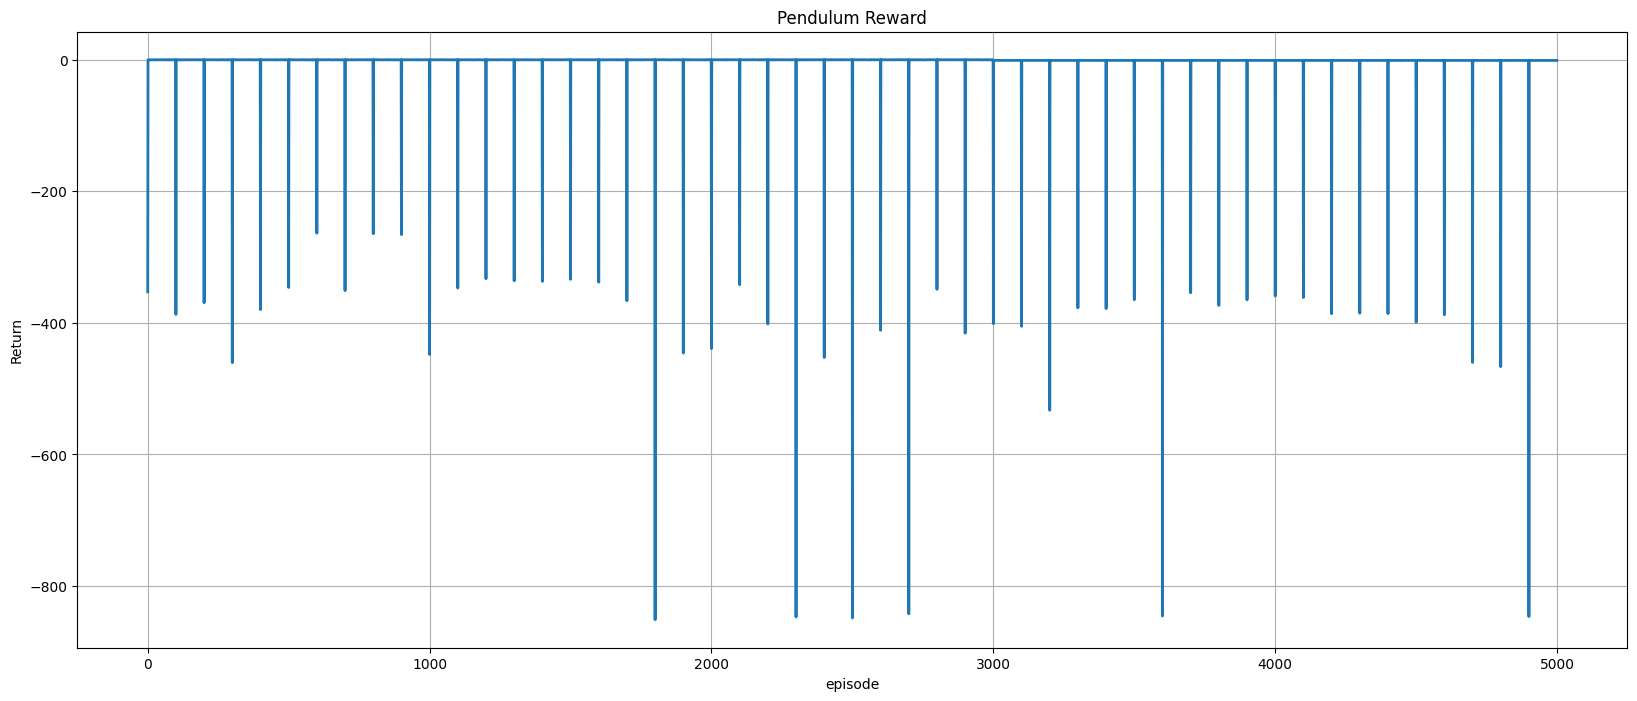

In [4]:
HORIZON = 200
GAMMA = 0.99
MU_P = 0
STD_DEV = 0.1

NUM_EPISODES = 5000

START = "up"
SEED = 42  
random.seed(SEED)
np.random.seed(SEED)

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0}_07_10-15_14_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
dp = KernelDataProcessor()




all_episode_rewards = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    done = False
    if i % 1000 == 0 :
        print(f"current mu = {MU_P}")
    if i % 100 == 0:
        MU_P = round(MU_P + 0.01, 2)
        env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")        
    env.reset(options={"start": "up"}, seed = i)
    if i % 100 == 0 :
        env.reset(options={"start": "down"}, seed = i)
    if i == 3000 :
        print(" ------- Simulating retrain at mu = 0.3")
        pol = DeepGaussianPolicy(
            parameters=np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl2_retrain/std{0.25}kl{0}_07_25-21_06_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_025_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )

    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        obs = dp.transform(obs)
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        episode_rewards.append(rew * GAMMA ** t)
    all_episode_rewards.append(sum(episode_rewards))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)

plt.figure(figsize=(20, 8))
plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Pendulum Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
#plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/lifelong/retrain03")

